In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report,confusion_matrix,roc_auc_score,
precision_recall_curve,average_precision_score,RocCurveDisplay)

In [2]:
df=pd.read_csv('ai4i2020.csv')

In [3]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
df.count()

UDI                        10000
Product ID                 10000
Type                       10000
Air temperature [K]        10000
Process temperature [K]    10000
Rotational speed [rpm]     10000
Torque [Nm]                10000
Tool wear [min]            10000
Machine failure            10000
TWF                        10000
HDF                        10000
PWF                        10000
OSF                        10000
RNF                        10000
dtype: int64

In [6]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [7]:
df["Machine failure"].value_counts(normalize=True)

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

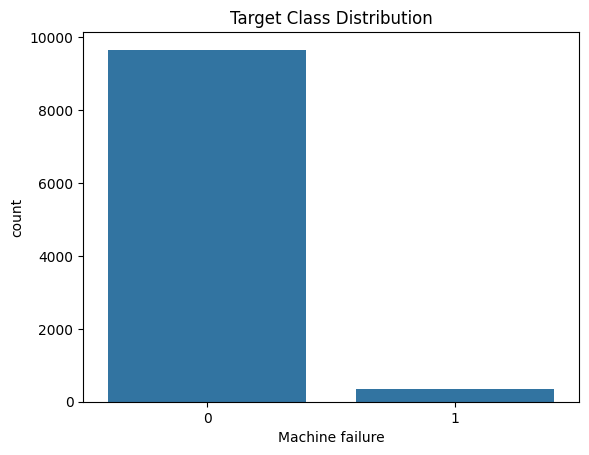

In [8]:
sns.countplot(x="Machine failure",data=df)
plt.title("Target Class Distribution")
plt.show()

In [9]:
#Failure - mode breakdown (multiple flags can co-occur)
failure_modes=["TWF","HDF","PWF","OSF","RNF"]
print(df[failure_modes].sum())

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


## Data Cleaning

In [10]:
# Drop identifier columns that carry no predictive signal
df=df.drop(columns=["UDI","Product ID"], errors="ignore")

In [11]:
# Check Duplicate / Missing value
print("Duplicate",df.duplicated().sum())
print("Missing Value:\n",df.isnull().sum())


Duplicate 0
Missing Value:
 Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [12]:
## In this dataset No duplicate data and no missing Values

In [13]:
# for safty_net
df=df.drop_duplicates()
df=df.dropna()

In [14]:
# Sanity check range (no negative torque/speed etc.)
assert (df["Torque [Nm]"]>=0).all()
assert (df["Rotational speed [rpm]"]>=0).all()

## EXPLORATARY DATA ANALYSIS (EDA)

In [16]:
failure_by_type=(df.groupby("Type")["Machine failure"].mean().mul(100))
print(failure_by_type)

Type
H    2.093719
L    3.916667
M    2.769436
Name: Machine failure, dtype: float64


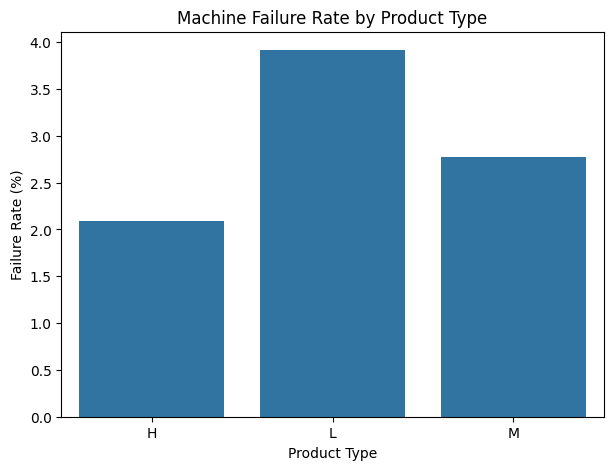

In [17]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=failure_by_type.index,
    y=failure_by_type.values
)

plt.title("Machine Failure Rate by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Failure Rate (%)")

plt.show()

In [18]:
numeric_cols=['Air temperature [K]','Process temperature [K]',
 'Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']

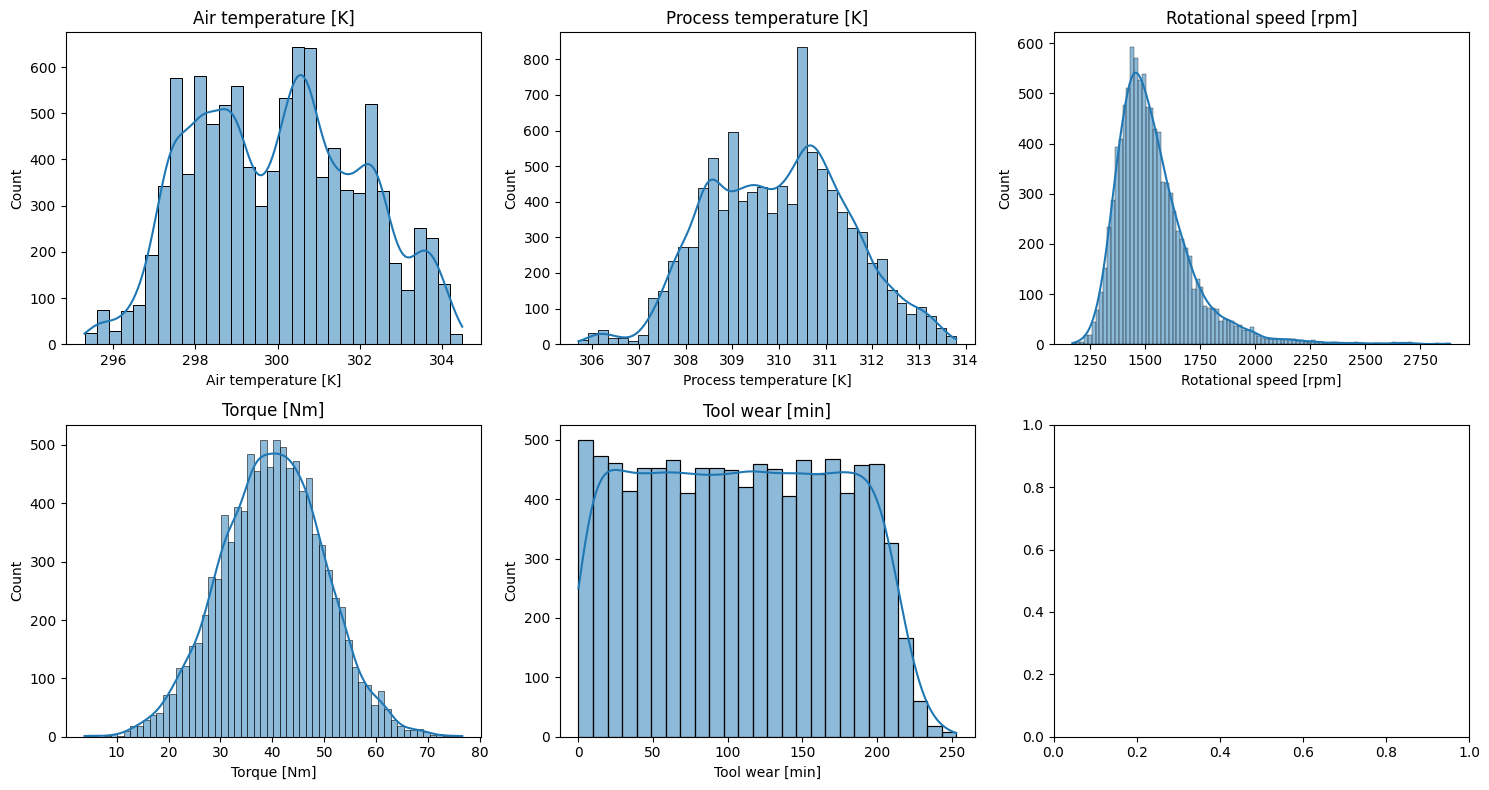

In [19]:
fig,axes=plt.subplots(2,3, figsize=(15,8))
for ax ,col in zip(axes.flat,numeric_cols):
    sns.histplot(df[col],kde=True,ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

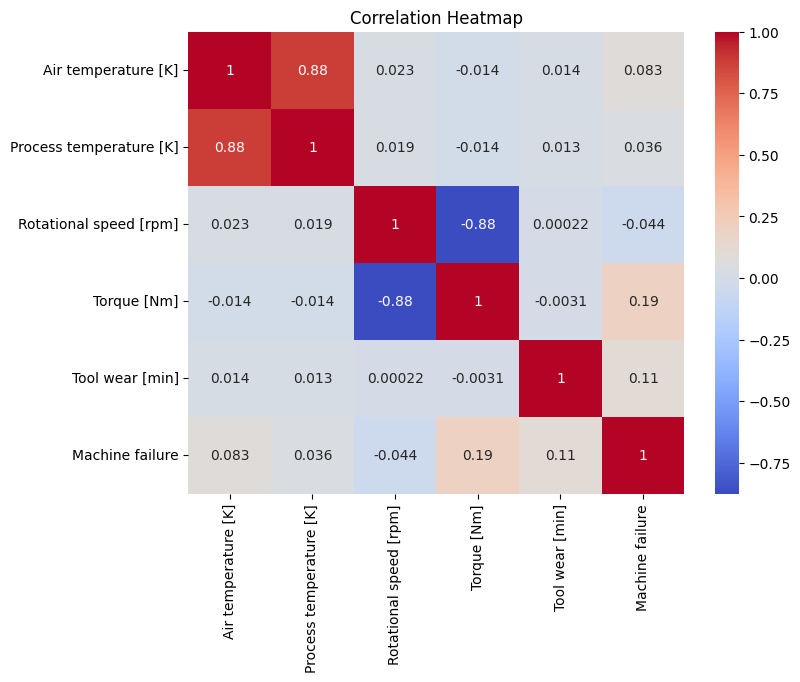

In [20]:
## Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols+["Machine failure"]].corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

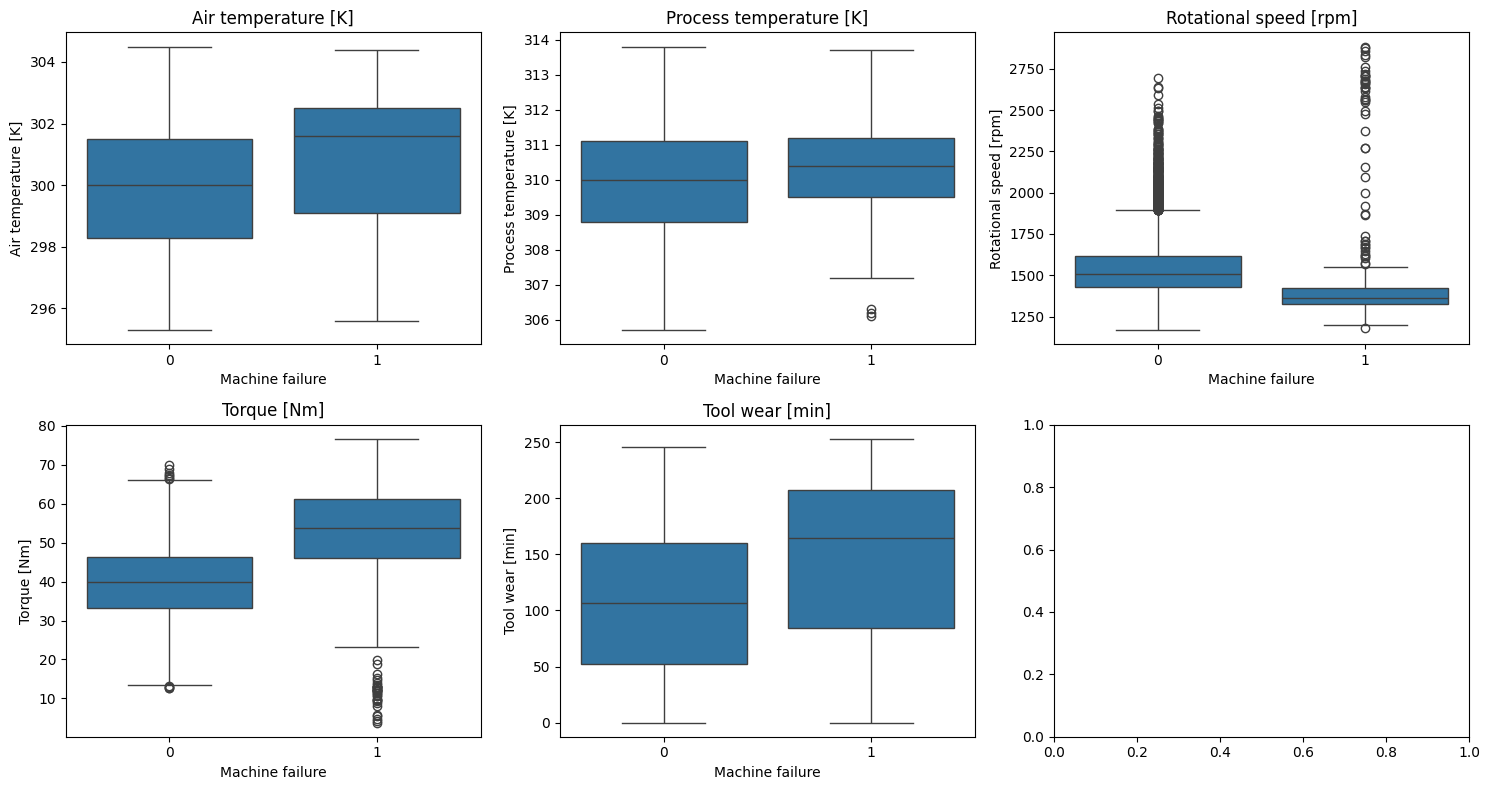

In [21]:
# BoxPlots: sensor readings split by failure outcome
fig,axes=plt.subplots(2,3, figsize=(15,8))
for ax ,col in zip(axes.flat,numeric_cols):
    sns.boxplot(x="Machine failure",data=df,y=col,ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## FEATURE ENGINEERING

In [26]:
df["Temp_diff"]=df["Process temperature [K]"]-df['Air temperature [K]']
df["Power"]=df["Torque [Nm]"]*df["Rotational speed [rpm]"]*(2*np.pi/60)
df["Wear_risk"]=pd.cut(
    df["Tool wear [min]"],bins=[-1,50,150,250,np.inf],
    labels=["low","medium","high","critical"]
)

In [27]:
## Drop the individual failure flags - they 'd leak target info
# (they are effectively sub -levels of Machine failure, not real features)
df=df.drop(columns=failure_modes)

KeyError: "['TWF', 'HDF', 'PWF', 'OSF', 'RNF'] not found in axis"

In [ ]:
print("Remaining failure-mode columns:",
      [col for col in failure_modes if col in df.columns])

## TRAIN TEST SPLIT

In [29]:
from sklearn.model_selection import train_test_split
X=df.drop(columns=["Machine failure"])
y=df["Machine failure"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Train failure rate:",y_train.mean(),"| Test failure rate:",y_test.mean())
print("Overall failure rate:", y.mean())

Train failure rate: 0.033875 | Test failure rate: 0.034
Overall failure rate: 0.0339


In [30]:
#Preprocessing
categorical_cols=["Type","Wear_risk"]
numeric_feature_cols=[c for c in X.columns if c not in categorical_cols]
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
preprocessor=ColumnTransformer(transformers=[
    ("num",StandardScaler(),numeric_feature_cols),
    ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_cols)
])

In [31]:
# Handling Imbalanced datas set via class_wieght
class_weight="balanced"

## Model Training

In [32]:
models={
    "LogisticRegression":LogisticRegression(class_weight=class_weight,max_iter=1000,random_state=42),
    "RandomForest":RandomForestClassifier(class_weight=class_weight,n_estimators=300,random_state=42)}
fitted_pipelines={}
for name, model in models.items():
    pipe=Pipeline([("prep",preprocessor),("clf",model)])
    pipe.fit(X_train,y_train)
    fitted_pipelines[name]=pipe
    print(f"Trained:{name}")

Trained:LogisticRegression
Trained:RandomForest


## Model Evaluation


===== LogisticRegression =====

===== RandomForest =====

Threshold: 0.2
              precision    recall  f1-score   support

           0      0.996     0.962     0.979      1932
           1      0.455     0.897     0.604        68

    accuracy                          0.960      2000
   macro avg      0.726     0.930     0.791      2000
weighted avg      0.978     0.960     0.966      2000

              precision    recall  f1-score   support

           0      0.991     0.997     0.994      1932
           1      0.893     0.735     0.806        68

    accuracy                          0.988      2000
   macro avg      0.942     0.866     0.900      2000
weighted avg      0.987     0.988     0.987      2000

Confusion matrix:
 [[1926    6]
 [  18   50]]
ROC-AUC: 0.9789725672877846
PR-AUC (Average Precision): 0.8516340597711304

Threshold: 0.3
              precision    recall  f1-score   support

           0      0.995     0.981     0.988      1932
           1      0.617   

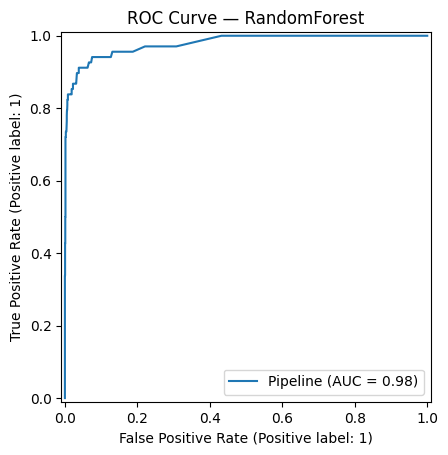

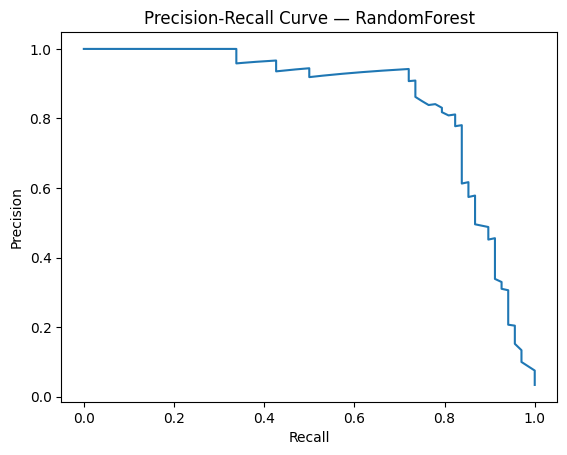

In [35]:
for name, pipe in fitted_pipelines.items():
    print(f"\n===== {name} =====")
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:

    y_pred_threshold = (
        y_proba >= threshold
    ).astype(int)

    print(f"\nThreshold: {threshold}")

    print(
        classification_report(
            y_test,
            y_pred_threshold,
            digits=3
        )
    )
    print(classification_report(y_test, y_pred, digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("PR-AUC (Average Precision):", average_precision_score(y_test, y_proba))

best_model_name = "RandomForest"  # pick based on recall/PR-AUC comparison above
best_pipe = fitted_pipelines[best_model_name]

RocCurveDisplay.from_estimator(best_pipe, X_test, y_test)
plt.title(f"ROC Curve — {best_model_name}")
plt.show()

precision, recall, thresholds = precision_recall_curve(
    y_test, best_pipe.predict_proba(X_test)[:, 1]
)
plt.plot(recall, precision)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve — {best_model_name}")
plt.show()